In [1]:
# [로컬 실행] Colab 마운트 불필요
# from google.colab import drive
# drive.mount("/content/drive")
# %cd /content/drive/MyDrive

In [2]:
from pathlib import Path

# [로컬 실행] 데이터는 같은 폴더의 PennFudanPed/ 에 이미 풀려 있음
#   (Colab) 아래 주석 코드로 zip 압축 해제
# import zipfile
# zip_file = "PennFudanPed.zip"
# data_path = Path("penn_data") / "PennFudanPed"
# with zipfile.ZipFile(zip_file, 'r') as files:
#     files.extractall(data_path)

# 노트북을 어느 cwd에서 실행해도 PennFudanPed 폴더를 찾음
for _cand in ['.', 'chap06/딥러닝 파이토치 교과서 6-2', '..']:
    if (Path(_cand) / 'PennFudanPed' / 'PNGImages').is_dir():
        data_path = Path(_cand); break
else:
    raise FileNotFoundError("PennFudanPed/PNGImages 를 못 찾았습니다")

print(f"Dataset path: {data_path.resolve()}")

Dataset path: /Users/namun/dev/A7608-2026-1-vision-dl/chap06/딥러닝 파이토치 교과서 6-2


In [3]:
import torch
import numpy as np
import torchvision.transforms.functional as func

from torch.utils.data import Dataset
from PIL import Image


class PennFudanDetection(Dataset):
  def __init__(self, root, image_size=320):
    self.root = Path(root)
    self.image_size = image_size

    self.images = sorted((self.root / "PennFudanPed" / "PNGImages").glob("*.png"))
    self.masks = sorted((self.root / "PennFudanPed" / "PedMasks").glob("*.png"))

  @staticmethod
  def get_collate_fn(batch):
    return tuple(zip(*batch))

  def __len__(self):
    return len(self.images)

  def __getitem__(self, index):
    image = Image.open(self.images[index]).convert("RGB")
    mask = Image.open(self.masks[index])

    image = image.resize((self.image_size, self.image_size))
    mask = mask.resize((self.image_size, self.image_size), resample=Image.Resampling.NEAREST)

    mask = np.array(mask)

    object_indices = np.unique(mask)
    object_indices = object_indices[object_indices != 0]                        # 0 means background

    boxes = []
    labels = []

    for object_index in object_indices:
      position = np.where(mask == object_index)

      y_min, y_max = np.min(position[0]), np.max(position[0])
      x_min, x_max = np.min(position[1]), np.max(position[1])

      if x_max > x_min and y_max > y_min:
        boxes.append([x_min, y_min, x_max, y_max])
        labels.append(1)                                                        # pedestrian class

    boxes = torch.as_tensor(boxes, dtype=torch.float32)
    labels = torch.as_tensor(labels, dtype=torch.int64)

    area = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])
    is_crowd = torch.zeros((len(boxes), ), dtype=torch.int64)

    image = func.to_tensor(image)

    target_auxiliary = {
        "boxes": boxes,
        "labels": labels,
        "image_index": torch.tensor([index]),
        "area": area,
        "is_crowd": is_crowd
    }

    return image, target_auxiliary

In [4]:
dataset = PennFudanDetection(root=data_path, image_size=320)

print(f"Total images: {len(dataset)}")

image, target = dataset[0]

print(
  f"Image shape: {image.shape}",
  f"Boxes shape: {target['boxes'].shape}",
  f"Labels: {target['labels']}",
  f"Boxes: {target['boxes']}"
)

Total images: 170
Image shape: torch.Size([3, 320, 320]) Boxes shape: torch.Size([2, 4]) Labels: tensor([1, 1]) Boxes: tensor([[ 91., 108., 172., 256.],
        [240., 101., 305., 289.]])


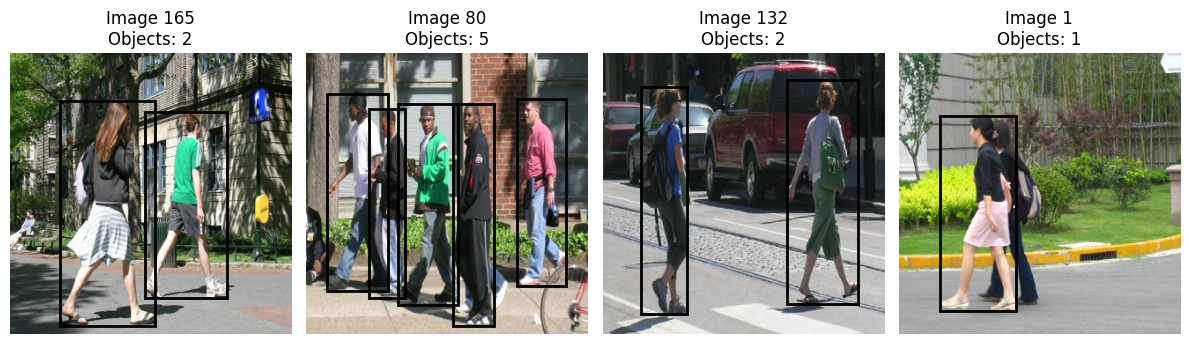

In [5]:
import random
import matplotlib.pyplot as plt


num_samples = 4
indices = random.sample(range(len(dataset)), k=num_samples)

plt.figure(figsize=(12, 6))

for i, index in enumerate(indices):
  image, target = dataset[index]
  np_image = image.permute(1, 2, 0).numpy()

  ax = plt.subplot(1, num_samples, i + 1)
  ax.imshow(np_image)

  for box in target["boxes"]:
    x_1, y_1, x_2, y_2 = box

    rectangle = plt.Rectangle(
        xy=(x_1, y_1),
        width=x_2-x_1,
        height=y_2-y_1,
        fill=False,
        linewidth=2
    )

    ax.add_patch(rectangle)

  ax.set_title(f"Image {index}\nObjects: {len(target['boxes'])}")
  ax.axis("off")

plt.tight_layout()
plt.show()


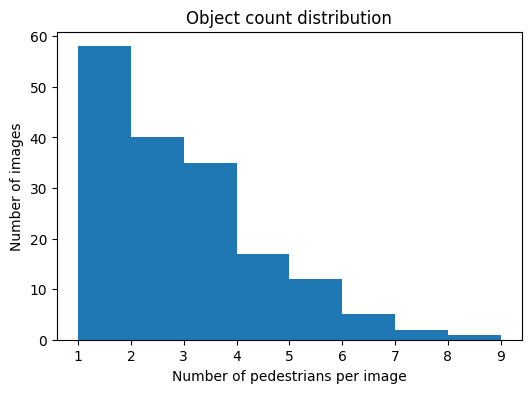

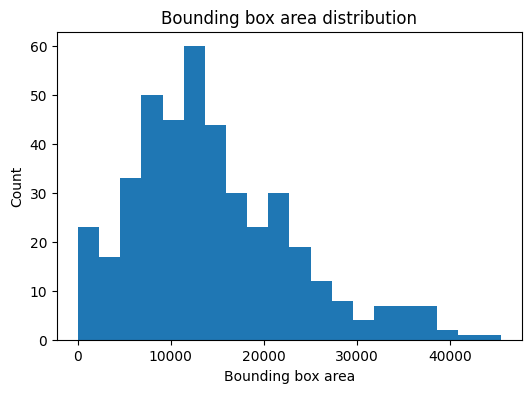

In [6]:
object_counts = []
box_areas = []

for index in range(len(dataset)):
    _, target = dataset[index]

    boxes = target["boxes"]
    object_counts.append(len(boxes))

    areas = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])
    box_areas.extend(areas.tolist())

plt.figure(figsize=(6, 4))
plt.hist(object_counts, bins=range(1, max(object_counts) + 2))
plt.xlabel("Number of pedestrians per image")
plt.ylabel("Number of images")
plt.title("Object count distribution")
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(box_areas, bins=20)
plt.xlabel("Bounding box area")
plt.ylabel("Count")
plt.title("Bounding box area distribution")
plt.show()

In [7]:
from torch.utils.data import Subset, DataLoader


torch.manual_seed(42)

indices = torch.randperm(len(dataset)).tolist()

train_indices = indices[:40]
valid_indices = indices[40:60]

train_dataset = Subset(dataset, train_indices)
valid_dataset = Subset(dataset, valid_indices)

# [로컬/CPU] num_workers=0, pin_memory=False (macOS 멀티프로세싱 회피 + GPU 없음)
train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True,
    collate_fn=PennFudanDetection.get_collate_fn,
    num_workers=0,
    pin_memory=False
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=1,
    shuffle=False,
    collate_fn=PennFudanDetection.get_collate_fn,
    num_workers=0,
    pin_memory=False
)

print("Train images:", len(train_dataset))
print("Val images:", len(valid_dataset))

Train images: 40
Val images: 20


In [ ]:
from torchvision.models.detection import (
    fasterrcnn_resnet50_fpn_v2,
    FasterRCNN_ResNet50_FPN_V2_Weights
)

# [zero-shot 방식] COCO 사전학습 가중치를 그대로 사용한다.
#   (원래는 box_predictor 분류 헤드를 2-class로 교체 후 fine-tuning 했으나,
#    학습이 수행되지 않아 모든 지표가 0이었다. 헤드를 교체하면 COCO가 배운
#    분류 능력이 사라지기 때문이다.)
#   COCO에는 이미 'person'(label==1) 클래스가 있으므로, 보행자=사람으로 보고
#   헤드를 건드리지 않고 추론만 한다 → 추가 학습 불필요.
# [로컬] torch 1.13의 MPS는 RPN의 topk(k>16)를 지원하지 않아 CPU를 사용한다.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

COCO_PERSON = 1  # COCO 클래스 인덱스에서 person == 1

weights = FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT
model = fasterrcnn_resnet50_fpn_v2(weights=weights)
model.to(device)

print(f"Device: {device}")
print("zero-shot COCO (학습 없음) — 'person' 클래스 예측만 평가")

In [ ]:
# [zero-shot] 학습 단계 생략
#   COCO 사전학습 모델을 그대로 사용하므로 별도 학습이 필요 없다.
#   (참고) 전이학습으로 fine-tuning 하려면 위 셀에서 box_predictor를
#   FastRCNNPredictor(in_features, 2)로 교체하고, lr=5e-4 수준의 낮은
#   학습률로 10 epoch 가량 학습해야 한다. lr=5e-3은 너무 커서 발산한다.
print("zero-shot: 학습 단계 생략")

In [ ]:
def visualize_prediction(model, dataset, index=0, score_threshold=0.5):
    model.eval()

    image, target = dataset[index]

    with torch.no_grad():
        predict = model([image.to(device)])[0]

    np_image = image.permute(1, 2, 0).cpu().numpy()

    plt.figure(figsize=(6, 6))
    plt.imshow(np_image)

    for box in target["boxes"]:
        x_1, y_1, x_2, y_2 = box
        plt.gca().add_patch(
            plt.Rectangle(
                (x_1, y_1),
                x_2 - x_1,
                y_2 - y_1,
                fill=False,
                linewidth=2,
                edgecolor="green"
            )
        )

    pred_boxes = predict["boxes"].cpu()
    pred_scores = predict["scores"].cpu()
    pred_labels = predict["labels"].cpu()

    for box, score, label in zip(pred_boxes, pred_scores, pred_labels):
        # zero-shot: COCO 'person'만, 점수 임계값 이상만 표시
        if label != COCO_PERSON or score < score_threshold:
            continue

        x_1, y_1, x_2, y_2 = box
        plt.gca().add_patch(
            plt.Rectangle(
                (x_1, y_1),
                x_2 - x_1,
                y_2 - y_1,
                fill=False,
                linewidth=2,
                edgecolor="red"
            )
        )
        plt.text(
            x_1,
            y_1,
            f"{score:.2f}",
            color="red",
            fontsize=10
        )

    plt.title("Green: Ground Truth / Red: Prediction(person)")
    plt.axis("off")
    plt.show()


visualize_prediction(model, valid_dataset, index=0, score_threshold=0.5)
visualize_prediction(model, valid_dataset, index=1, score_threshold=0.5)

In [ ]:
def box_iou(boxes1, boxes2):
    if len(boxes1) == 0 or len(boxes2) == 0:
        return torch.zeros((len(boxes1), len(boxes2)))

    area1 = (boxes1[:, 2] - boxes1[:, 0]).clamp(min=0) * \
            (boxes1[:, 3] - boxes1[:, 1]).clamp(min=0)
    area2 = (boxes2[:, 2] - boxes2[:, 0]).clamp(min=0) * \
            (boxes2[:, 3] - boxes2[:, 1]).clamp(min=0)

    lt = torch.max(boxes1[:, None, :2], boxes2[:, :2])
    rb = torch.min(boxes1[:, None, 2:], boxes2[:, 2:])

    wh = (rb - lt).clamp(min=0)
    inter = wh[:, :, 0] * wh[:, :, 1]

    union = area1[:, None] + area2 - inter

    return inter / union.clamp(min=1e-6)


def evaluate_simple(model, data_loader, score_threshold=0.5, iou_threshold=0.5):
    model.eval()

    total_tp = 0
    total_fp = 0
    total_fn = 0
    matched_ious = []

    with torch.no_grad():
        for images, targets in data_loader:
            images = [img.to(device) for img in images]
            outputs = model(images)

            for output, target in zip(outputs, targets):
                pred_boxes = output["boxes"].cpu()
                pred_scores = output["scores"].cpu()
                pred_labels = output["labels"].cpu()

                # zero-shot: COCO 'person' + 점수 임계값 이상만 사용
                keep = (pred_labels == COCO_PERSON) & (pred_scores >= score_threshold)
                pred_boxes = pred_boxes[keep]

                gt_boxes = target["boxes"].cpu()

                if len(pred_boxes) == 0:
                    total_fn += len(gt_boxes)
                    continue

                if len(gt_boxes) == 0:
                    total_fp += len(pred_boxes)
                    continue

                ious = box_iou(pred_boxes, gt_boxes)

                matched_gt = set()

                for pred_idx in range(len(pred_boxes)):
                    best_iou, best_gt_idx = ious[pred_idx].max(dim=0)
                    best_gt_idx = int(best_gt_idx)

                    if best_iou >= iou_threshold and best_gt_idx not in matched_gt:
                        total_tp += 1
                        matched_gt.add(best_gt_idx)
                        matched_ious.append(float(best_iou))
                    else:
                        total_fp += 1

                total_fn += len(gt_boxes) - len(matched_gt)

    precision = total_tp / max(total_tp + total_fp, 1)
    recall = total_tp / max(total_tp + total_fn, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-6)
    mean_iou = np.mean(matched_ious) if matched_ious else 0.0

    return {
        "TP": total_tp,
        "FP": total_fp,
        "FN": total_fn,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Mean IoU": mean_iou
    }


# zero-shot 이므로 학습/검증 분할이 의미 없다 → 전체 170장으로 평가한다.
full_loader = DataLoader(
    dataset,
    batch_size=2,
    shuffle=False,
    collate_fn=PennFudanDetection.get_collate_fn,
    num_workers=0,
    pin_memory=False
)

# 점수 임계값별 정밀도-재현율 트레이드오프 확인
results = {}
for th in (0.5, 0.7):
    results[th] = evaluate_simple(model, full_loader, score_threshold=th, iou_threshold=0.5)
    m = results[th]
    print(f"[score>={th}] TP {m['TP']} FP {m['FP']} FN {m['FN']} | "
          f"P {m['Precision']:.3f} R {m['Recall']:.3f} "
          f"F1 {m['F1']:.3f} mIoU {m['Mean IoU']:.3f}")

# 다음 셀(막대그래프)용: 기본 임계값 0.5 결과
metrics = results[0.5]
metrics

In [ ]:
names = ["Precision", "Recall", "F1", "Mean IoU"]
values = [metrics[k] for k in names]

plt.figure(figsize=(6, 4))
plt.bar(names, values)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Validation metrics (zero-shot, score>=0.5)")
plt.show()

for key, value in metrics.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")